<a href="https://colab.research.google.com/github/riturajs19/RNN-Movie-Review/blob/main/SimpleRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from tensorflow.keras.preprocessing.text import one_hot

In [36]:
### sentences
sent=[  'the glass of milk',
     'the glass of juice',
     'the cup of tea',
    'I am a good boy',
     'I am a good developer',
     'understand the meaning of words',
     'your videos are good',]

In [37]:
 ## Now we will creste vocab size
 voc_size = 10000

In [38]:
# Now one hot representation
onehot_repr = [one_hot(words, voc_size) for words in sent]
print(onehot_repr)

[[4154, 8138, 1522, 9910], [4154, 8138, 1522, 8974], [4154, 7796, 1522, 1782], [3574, 4187, 5319, 5963, 1257], [3574, 4187, 5319, 5963, 646], [2975, 4154, 8260, 1522, 6843], [8463, 3586, 1289, 5963]]


In [39]:
## Word Embedding Representation
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

In [40]:
## Now we will do padding
import numpy as np
sent_length = 8
embedded_docs = np.array(pad_sequences(onehot_repr, padding='pre', maxlen=sent_length))
embedded_docs

array([[   0,    0,    0,    0, 4154, 8138, 1522, 9910],
       [   0,    0,    0,    0, 4154, 8138, 1522, 8974],
       [   0,    0,    0,    0, 4154, 7796, 1522, 1782],
       [   0,    0,    0, 3574, 4187, 5319, 5963, 1257],
       [   0,    0,    0, 3574, 4187, 5319, 5963,  646],
       [   0,    0,    0, 2975, 4154, 8260, 1522, 6843],
       [   0,    0,    0,    0, 8463, 3586, 1289, 5963]], dtype=int32)

In [41]:
## Feature Representation
dim =10

In [42]:
model = Sequential()
model.add(Embedding(input_dim=voc_size, output_dim=dim, input_shape=(sent_length,)))
model.compile('adam', 'mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 8, 10)          │       100,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,000 (390.62 KB)

 Trainable params: 100,000 (390.62 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.predict(embedded_docs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


array([[[ 0.0302338 , -0.04221412,  0.02477597,  0.0109293 ,
          0.0257823 , -0.04795728, -0.02512257,  0.01591266,
          0.03094831,  0.00541651],
        [ 0.0302338 , -0.04221412,  0.02477597,  0.0109293 ,
          0.0257823 , -0.04795728, -0.02512257,  0.01591266,
          0.03094831,  0.00541651],
        [ 0.0302338 , -0.04221412,  0.02477597,  0.0109293 ,
          0.0257823 , -0.04795728, -0.02512257,  0.01591266,
          0.03094831,  0.00541651],
        [ 0.0302338 , -0.04221412,  0.02477597,  0.0109293 ,
          0.0257823 , -0.04795728, -0.02512257,  0.01591266,
          0.03094831,  0.00541651],
        [-0.00458399,  0.02875871, -0.03780108,  0.00043824,
          0.02476266, -0.04551839, -0.00102371,  0.02638048,
         -0.00744568,  0.03749539],
        [-0.01116852,  0.04604342, -0.02943069,  0.01720459,
          0.01521024, -0.0442769 ,  0.01927613,  0.0141107 ,
          0.00259496,  0.00495738],
        [ 0.01841201,  0.00037514, -0.01162942,  0.0

# Project Implementation

In [44]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from tensorflow.keras.preprocessing import sequence

In [45]:
## Load the imdb dataset
max_features = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

In [46]:
### Print the shape of the data
print(X_train.shape)
print(X_test.shape)

(25000,)
(25000,)


In [47]:
print(len(X_train[0]))
print(len(X_train[1]))

218
189


In [48]:
## Inspect sample review and label
sample_review = X_train[0]
sample_label = y_train[0]
print("Sample Review:", sample_review)
print("Sample Label:", sample_label)

Sample Review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample Label: 1


In [49]:
## Mappings of word index back to word
word_index = imdb.get_word_index()
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [50]:
## Reverse word index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [51]:
## Now we will do padding
max_len = 500
X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

In [52]:
X_train

array([[   0,    0,    0, ...,   19,  178,   32],
       [   0,    0,    0, ...,   16,  145,   95],
       [   0,    0,    0, ...,    7,  129,  113],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]], dtype=int32)

In [53]:
## Train Simple RNN
model = Sequential()

model.add(Embedding(input_dim=max_features, output_dim=128, input_shape=(max_len,)))
model.add(SimpleRNN(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
## Now we will create instance of early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [55]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [56]:
## Train the model with early stopping
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.6286 - loss: 25.7877 - val_accuracy: 0.7733 - val_loss: 0.4873
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.8084 - loss: 0.4305 - val_accuracy: 0.8029 - val_loss: 0.4263
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8384 - loss: 0.3922 - val_accuracy: 0.8114 - val_loss: 0.4292
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8790 - loss: 0.2979 - val_accuracy: 0.8011 - val_loss: 0.4392
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9022 - loss: 0.2499 - val_accuracy: 0.7298 - val_loss: 0.5494
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9124 - loss: 0.2295 - val_accuracy: 0.8012 - val_loss: 0.4925
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9336 - loss: 0.1794 - val_accuracy: 0.6965 - val_loss: 0.9454


In [57]:
history.history

{'accuracy': [0.628600001335144,
  0.8083999752998352,
  0.8384000062942505,
  0.879040002822876,
  0.902239978313446,
  0.9124400019645691,
  0.9336400032043457],
 'loss': [25.787694931030273,
  0.4304712414741516,
  0.39217033982276917,
  0.29787614941596985,
  0.24989113211631775,
  0.22947213053703308,
  0.1793820559978485],
 'val_accuracy': [0.7732800245285034,
  0.8028799891471863,
  0.8113999962806702,
  0.8011199831962585,
  0.7297999858856201,
  0.8011599779129028,
  0.6965199708938599],
 'val_loss': [0.4873499274253845,
  0.4262630045413971,
  0.429172545671463,
  0.43915870785713196,
  0.5493530631065369,
  0.49251872301101685,
  0.9453657269477844]}

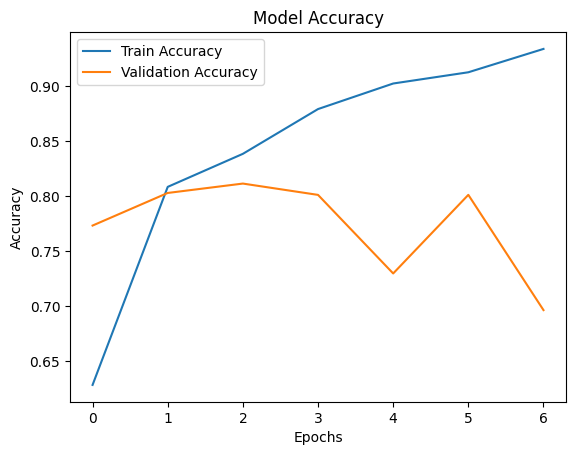

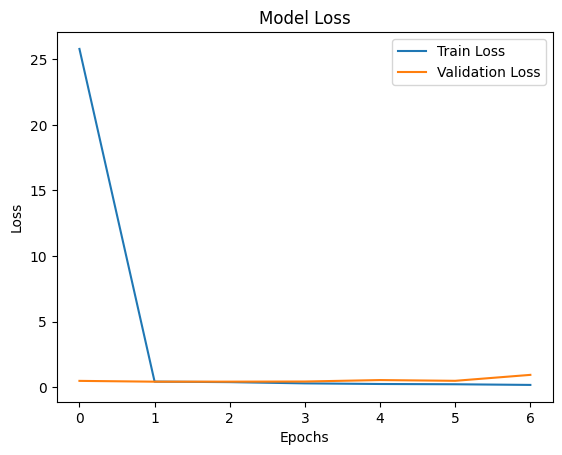

In [58]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()


# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [59]:
## Now we will save the model
model.save('simple_rnn_model.h5')

In [60]:
from tensorflow.keras.models import load_model

In [61]:
## Now we will load the file
model = load_model('simple_rnn_model.h5')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,027 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [62]:
len(model.get_weights())

6

In [72]:
# Function to decode reviews
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# Function to preprocess user input
def preprocess_text(text):
    words = text.lower().split()
    encoded_review = [word_index.get(word, 2) + 3 for word in words]
    padded_review = sequence.pad_sequences([encoded_review], maxlen=500)
    return padded_review

In [73]:
def predict_sentiment(review):
    preprocessed_input=preprocess_text(review)

    prediction=model.predict(preprocessed_input)

    sentiment = 'Positive' if prediction[0][0] > 0.5 else 'Negative'

    return sentiment, prediction[0][0]


In [74]:
example_review = "This movie was fantastic! The acting was great and the plot was thrilling."

sentiment,score=predict_sentiment(example_review)

print(f'Review: {example_review}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Review: This movie was fantastic! The acting was great and the plot was thrilling.
Sentiment: Positive
Prediction Score: 0.8245278596878052


In [75]:
example_review = "This movie was worst! The acting was terrible and the plot was worst."

sentiment,score=predict_sentiment(example_review)

print(f'Review: {example_review}')
print(f'Sentiment: {sentiment}')
print(f'Prediction Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Review: This movie was worst! The acting was terrible and the plot was worst.
Sentiment: Positive
Prediction Score: 0.6327593326568604
